
# CELL 1: IMPORT LIBRARIES



In [ ]:
# System operations
import os
import shutil

# Numerical computation
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# XML annotation parsing
import xml.etree.ElementTree as ET

# EDF signal processing
import mne

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Handle class imbalance
from sklearn.utils import class_weight

# CELL 2: GLOBAL CONFIGURATION

In [3]:

# Target signal channel
CHANNELS = ['EOG-R']

# Resampling frequency
TARGET_SFREQ = 100

# Epoch duration in seconds
EPOCH_SEC = 30

# Number of samples per epoch
EPOCH_LENGTH = TARGET_SFREQ * EPOCH_SEC

# Number of sleep classes
NUM_CLASSES = 5

# Class names
CLASS_NAMES = ["Wake", "N1", "N2", "N3", "REM"]

# Mapping XML labels → numeric labels
STAGE_MAPPING = {
    "Wake|0": 0,
    "Stage 1 sleep|1": 1,
    "Stage 2 sleep|2": 2,
    "Stage 3 sleep|3": 3,
    "REM sleep|5": 4
}

# Visualization colors
STAGE_COLORS = {
    "Wake|0": "red",
    "Stage 1 sleep|1": "lightblue",
    "Stage 2 sleep|2": "blue",
    "Stage 3 sleep|3": "darkblue",
    "REM sleep|5": "green"
}

print("Configuration loaded successfully.")
print(f"Epoch Length = {EPOCH_LENGTH} samples")

Configuration loaded successfully.
Epoch Length = 3000 samples


# CELL 3: VISUALIZE FULL SIGNAL

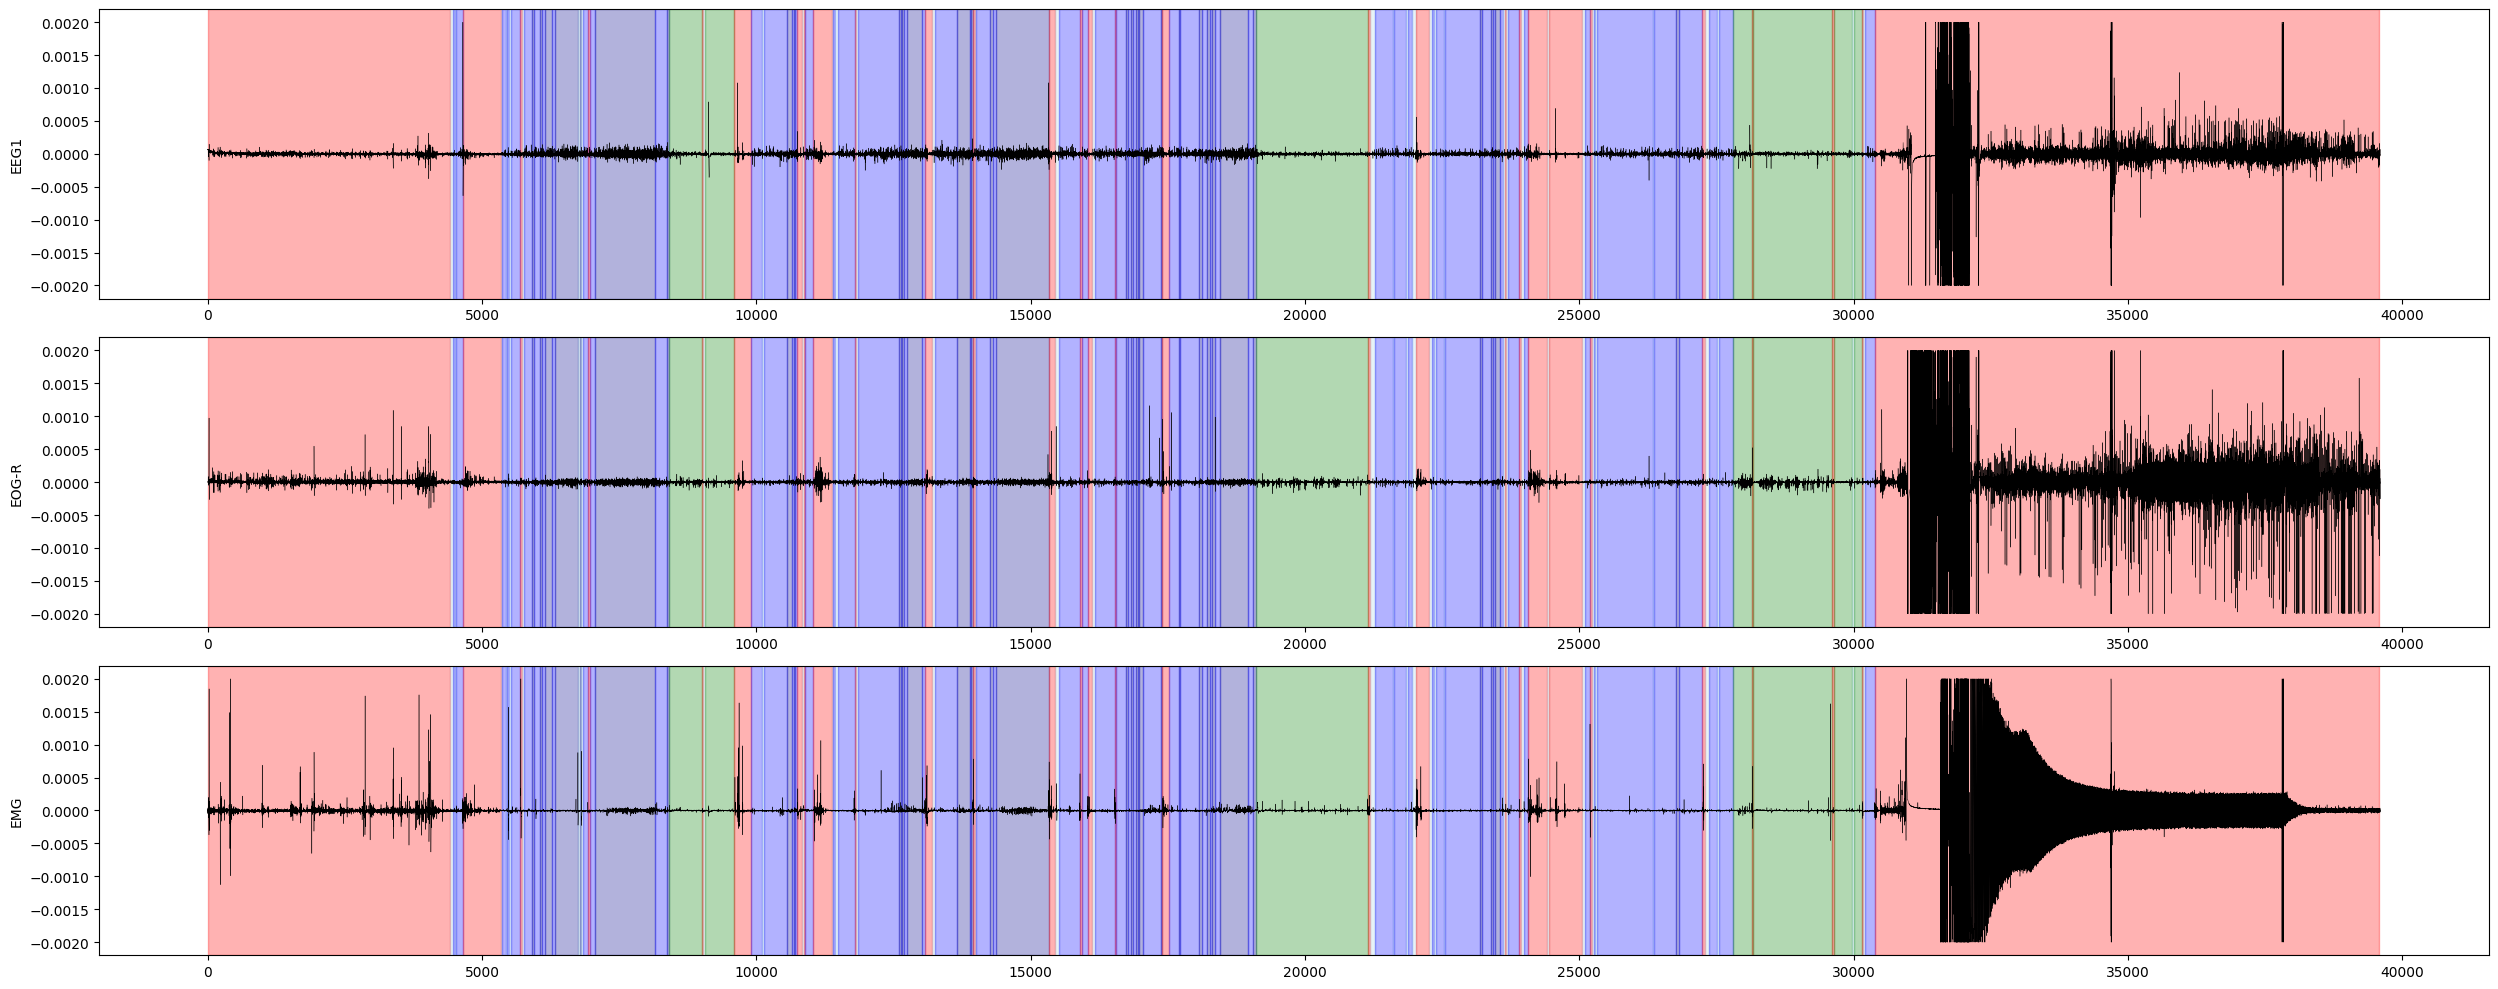

In [4]:

edf_file = "Dataset/Signals/mesa-sleep-0002.edf"
xml_file = "Dataset/Annotations/mesa-sleep-0002-nsrr.xml"

channels_to_plot = ["EEG1", "EOG-R", "EMG"]

# Parse annotations
tree = ET.parse(xml_file)
root = tree.getroot()

events = [
    e for e in root.findall(".//ScoredEvent")
    if e.find("EventType").text == "Stages|Stages"
]

# Load EDF file
raw = mne.io.read_raw_edf(edf_file, preload=False, verbose=False)
sfreq = raw.info["sfreq"]

plt.figure(figsize=(25, 10))

for i, ch in enumerate(channels_to_plot):
    ax = plt.subplot(len(channels_to_plot), 1, i + 1)

    data = raw.get_data(picks=ch)[0]
    times = np.arange(len(data)) / sfreq

    # Downsample for faster plotting
    step = 200
    data = data[::step]
    times = times[::step]

    ax.plot(times, data, color="black", linewidth=0.3)

    for e in events:
        start = float(e.find("Start").text)
        duration = float(e.find("Duration").text)
        stage = e.find("EventConcept").text

        ax.axvspan(
            start,
            start + duration,
            color=STAGE_COLORS.get(stage, "gray"),
            alpha=0.3
        )

    ax.set_ylabel(ch)

plt.tight_layout()
plt.show()

# CELL 4: VISUALIZE  SIGNAL EOG-R

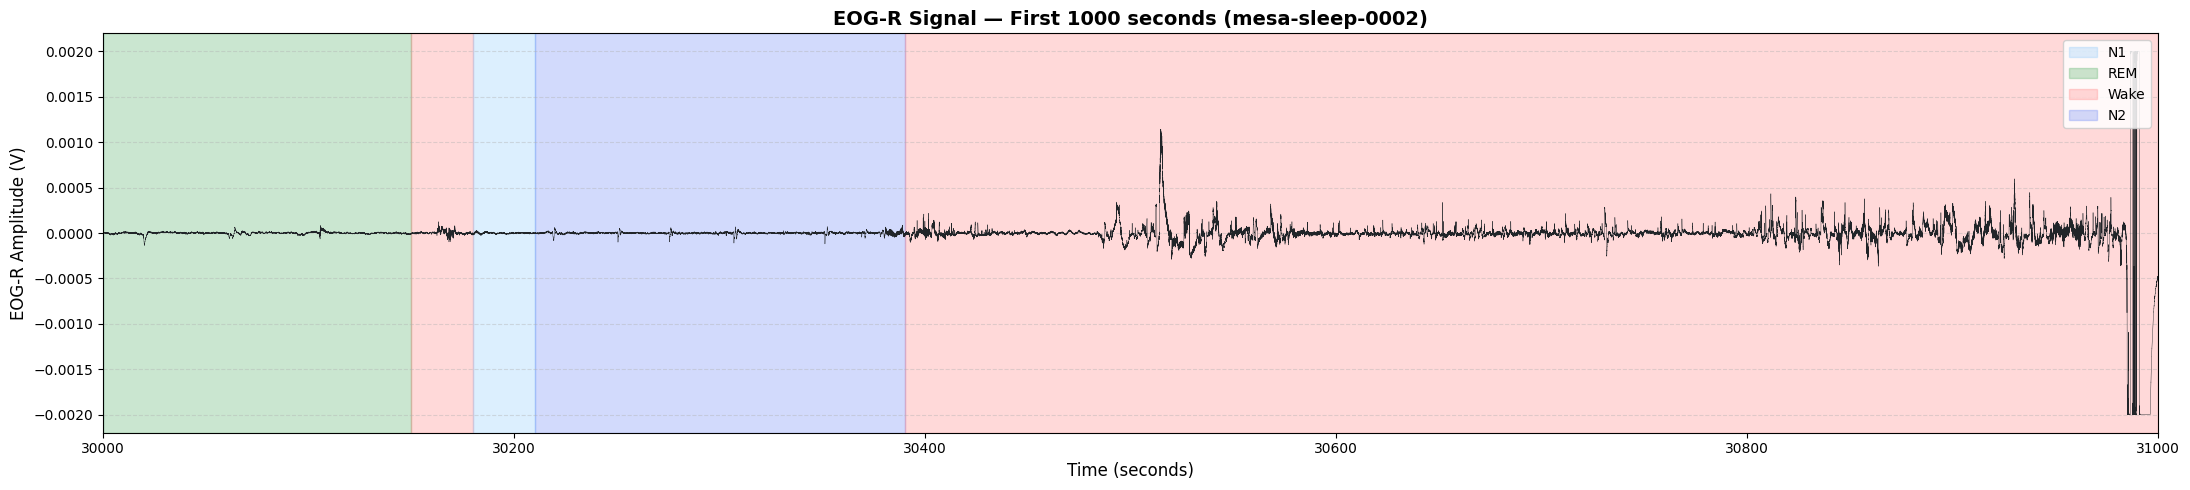

✅ Done! Saved as eog_signal_preview.png


In [5]:

edf_file = "Dataset/Signals/mesa-sleep-0002.edf"
xml_file = "Dataset/Annotations/mesa-sleep-0002-nsrr.xml"

START_SEC = 30000   
DURATION_SEC = 1000 


tree = ET.parse(xml_file)
root = tree.getroot()
events = [e for e in root.findall(".//ScoredEvent")
          if e.find("EventType").text == "Stages|Stages"]

stage_colors = {
    "Wake|0":           ("#FF6B6B", "Wake"),
    "Stage 1 sleep|1":  ("#74C0FC", "N1"),
    "Stage 2 sleep|2":  ("#4C6EF5", "N2"),
    "Stage 3 sleep|3":  ("#1864AB", "N3"),
    "REM sleep|5":      ("#2F9E44", "REM"),
}


raw = mne.io.read_raw_edf(edf_file, preload=False, verbose=False)
sfreq = raw.info['sfreq']

start_sample = int(START_SEC * sfreq)
end_sample   = int((START_SEC + DURATION_SEC) * sfreq)

data = raw.get_data(picks='EOG-R')[0]
data = data[start_sample:end_sample]
times = np.arange(len(data)) / sfreq + START_SEC


fig, ax = plt.subplots(figsize=(22, 5))


ax.plot(times, data, color='#212529', linewidth=0.3, zorder=2)

legend_added = set()
for e in events:
    start = float(e.find("Start").text)
    dur   = float(e.find("Duration").text)
    stage = e.find("EventConcept").text

    if start + dur < START_SEC or start > START_SEC + DURATION_SEC:
        continue

    color, label = stage_colors.get(stage, ("#CCC", "Unknown"))
    show_label = label if label not in legend_added else ""
    if show_label:
        legend_added.add(label)

    ax.axvspan(max(start, START_SEC), min(start + dur, START_SEC + DURATION_SEC),
               color=color, alpha=0.25, label=show_label, zorder=1)


ax.set_xlim(START_SEC, START_SEC + DURATION_SEC)
ax.set_xlabel("Time (seconds)", fontsize=12)
ax.set_ylabel("EOG-R Amplitude (V)", fontsize=12)
ax.set_title(f"EOG-R Signal — First {DURATION_SEC} seconds (mesa-sleep-0002)", fontsize=14, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.85, fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("eog_signal_preview.png", dpi=150)
plt.show()
print("✅ Done! Saved as eog_signal_preview.png")

# CELL 5: TRAIN / VAL / TEST SPLIT


In [6]:

EDF_DIR = "Dataset/Signals"
XML_DIR = "Dataset/Annotations"

files = sorted([
    f.replace(".edf", "")
    for f in os.listdir(EDF_DIR)
    if f.endswith(".edf")
])

np.random.seed(42)
np.random.shuffle(files)

n = len(files)

train_end = int(n * 0.6)
val_end = int(n * 0.8)

train_files = files[:train_end]
val_files = files[train_end:val_end]
test_files = files[val_end:]

print(f"Train Subjects: {len(train_files)}")
print(f"Validation Subjects: {len(val_files)}")
print(f"Test Subjects: {len(test_files)}")

Train Subjects: 3
Validation Subjects: 1
Test Subjects: 1


# CELL 6: PREPROCESSING FUNCTION
    Preprocess one EDF record:
    1. Load target channel
    2. Filter
    3. Resample
    4. Normalize
    5. Segment into epochs


In [7]:

def process_single_record(edf_path, xml_path):
  

    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)

    raw.pick(CHANNELS)

    raw.load_data()

    # Bandpass filter
    raw.filter(
        l_freq=0.5,
        h_freq=20.0,
        fir_design='firwin',
        verbose=False
    )

    # Resample
    raw.resample(TARGET_SFREQ)

    data = raw.get_data().T

    # Z-score normalization
    mean = np.mean(data)
    std = np.std(data)

    if std > 0:
        data = (data - mean) / std

    # Clip extreme values
    data = np.clip(data, -5, 5)

    # Parse labels
    tree = ET.parse(xml_path)
    root = tree.getroot()

    events = [
        e for e in root.findall(".//ScoredEvent")
        if e.find("EventType").text == "Stages|Stages"
    ]

    num_epochs = data.shape[0] // EPOCH_LENGTH

    labels = np.full(num_epochs, -1)

    for e in events:
        start = float(e.find("Start").text)
        duration = float(e.find("Duration").text)
        stage = e.find("EventConcept").text

        if stage in STAGE_MAPPING:
            start_epoch = int(start / EPOCH_SEC)
            n_epochs = int(duration / EPOCH_SEC)

            labels[start_epoch:start_epoch+n_epochs] = STAGE_MAPPING[stage]

    data = data[:num_epochs * EPOCH_LENGTH]

    X = data.reshape(num_epochs, EPOCH_LENGTH, 1)
    y = labels

    valid = y != -1

    return X[valid], y[valid]

# CELL 6: LOAD PROCESSED DATA

In [8]:

train_npz = np.load("Dataset/Processed/train/train_data.npz")
val_npz   = np.load("Dataset/Processed/val/val_data.npz")
test_npz  = np.load("Dataset/Processed/test/test_data.npz")

X_train, y_train = train_npz['X'], train_npz['y']
X_val, y_val = val_npz['X'], val_npz['y']
X_test, y_test = test_npz['X'], test_npz['y']

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (2746, 3000, 1)
Val: (1079, 3000, 1)
Test: (2638, 3000, 1)


# CELL 8: CLASS DISTRIBUTION

In [9]:

def analyze_distribution(y, name):
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)

    print(f"\n{name} Distribution")

    for i, cls in enumerate(CLASS_NAMES):
        n = dict(zip(unique, counts)).get(i, 0)
        print(f"{cls}: {n} ({100*n/total:.2f}%)")

analyze_distribution(y_train, "Training")
analyze_distribution(y_val, "Validation")
analyze_distribution(y_test, "Testing")


Training Distribution
Wake: 1453 (52.91%)
N1: 134 (4.88%)
N2: 738 (26.88%)
N3: 172 (6.26%)
REM: 249 (9.07%)

Validation Distribution
Wake: 364 (33.73%)
N1: 141 (13.07%)
N2: 380 (35.22%)
N3: 75 (6.95%)
REM: 119 (11.03%)

Testing Distribution
Wake: 1732 (65.66%)
N1: 155 (5.88%)
N2: 581 (22.02%)
N3: 92 (3.49%)
REM: 78 (2.96%)


# CELL 8: CLASS WEIGHTS

In [10]:

weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

CLASS_WEIGHTS = {
    i: min(w, 2.0)
    for i, w in enumerate(weights)
}

print(CLASS_WEIGHTS)

{0: np.float64(0.3779766001376462), 1: 2.0, 2: np.float64(0.7441734417344174), 3: 2.0, 4: 2.0}


# Model Architecture

This section defines the deep learning architecture used for sleep stage classification from the EOG-R signal.

The model combines:

* **Squeeze-and-Excitation (SE) blocks** for adaptive channel weighting
* **Residual Convolutional blocks** for hierarchical feature extraction
* **Bidirectional LSTM layers** for temporal dependency modeling
* **Multi-Head Self-Attention** for long-range sequence interaction
* **Dual Pooling and Dense layers** for final classification

The input shape is:

* **3000 samples per epoch**
* **1 signal channel (EOG-R)**

The output is a probability distribution over the 5 sleep stages:

* Wake
* N1
* N2
* N3
* REM


In [ ]:

# Clear previous TensorFlow session to free memory
tf.keras.backend.clear_session()

# SQUEEZE-AND-EXCITATION BLOCK
def se_block(x, ratio=16):


    filters = x.shape[-1]

    # Global context extraction
    se = layers.GlobalAveragePooling1D()(x)

    # Bottleneck compression
    se = layers.Dense(
        max(filters // ratio, 8),
        activation='relu'
    )(se)

    # Channel-wise scaling weights
    se = layers.Dense(
        filters,
        activation='sigmoid'
    )(se)

    # Reshape for broadcasting
    se = layers.Reshape((1, filters))(se)

    # Apply attention weights
    return layers.Multiply()([x, se])

# RESIDUAL CONVOLUTIONAL BLOCK
def residual_conv_block(x, filters, kernel_size, strides=1):
 

    shortcut = x

    # First convolution
    out = layers.Conv1D(
        filters,
        kernel_size,
        strides=strides,
        padding='same',
        use_bias=False
    )(x)

    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out)

    # Second convolution
    out = layers.Conv1D(
        filters,
        kernel_size,
        strides=1,
        padding='same',
        use_bias=False
    )(out)

    out = layers.BatchNormalization()(out)

    # Channel attention
    out = se_block(out)

    # Match shortcut dimensions if needed
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(
            filters,
            1,
            strides=strides,
            padding='same',
            use_bias=False
        )(shortcut)

        shortcut = layers.BatchNormalization()(shortcut)

    # Residual addition
    out = layers.Add()([out, shortcut])

    return layers.Activation('relu')(out)
# TEMPORAL SELF-ATTENTION BLOCK
def temporal_attention_block(x, num_heads=4):
 

    embed_dim = x.shape[-1]

    # Multi-head self-attention
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=0.1
    )(x, x)

    # Residual + normalization
    attn = layers.LayerNormalization(
        epsilon=1e-6
    )(layers.Add()([x, attn]))

    # Feed-forward network
    ff = layers.Dense(
        embed_dim * 2,
        activation='gelu'
    )(attn)

    ff = layers.Dense(embed_dim)(ff)

    ff = layers.Dropout(0.1)(ff)

    # Final residual connection
    return layers.LayerNormalization(
        epsilon=1e-6
    )(layers.Add()([attn, ff]))

# FULL MODEL
def build_model(input_shape, num_classes=5):
  

    inputs = layers.Input(shape=input_shape)

    # STEM BLOCK
    # kernel_size=25 captures slow EOG eye-movement dynamics
    x = layers.Conv1D(
        64,
        kernel_size=25,
        strides=2,
        padding='same',
        use_bias=False
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.MaxPooling1D(
        pool_size=2,
        strides=2
    )(x)

    # Output shape: (750, 64)
    # STAGE 1
    x = residual_conv_block(
        x,
        filters=128,
        kernel_size=7
    )

    x = residual_conv_block(
        x,
        filters=128,
        kernel_size=7
    )

    x = layers.MaxPooling1D(
        pool_size=2,
        strides=2
    )(x)

    # Output shape: (187, 128)
    # STAGE 2
    x = residual_conv_block(
        x,
        filters=256,
        kernel_size=5
    )

    x = residual_conv_block(
        x,
        filters=256,
        kernel_size=5
    )

    x = layers.MaxPooling1D(
        pool_size=2,
        strides=2
    )(x)

    x = layers.Dropout(0.3)(x)

    # Output shape: (46, 256)
    # BIDIRECTIONAL LSTM BLOCK
    # First BiLSTM
    x = layers.Bidirectional(
        layers.LSTM(
            128,
            return_sequences=True,
            dropout=0.2,
            recurrent_dropout=0.1
        )
    )(x)

    # Output shape: (46, 256)
    # Second BiLSTM
    x = layers.Bidirectional(
        layers.LSTM(
            64,
            return_sequences=True,
            dropout=0.2,
            recurrent_dropout=0.1
        )
    )(x)

    # Output shape: (46, 128)
    # TEMPORAL SELF-ATTENTION
    x = temporal_attention_block(
        x,
        num_heads=4
    )

    # DUAL GLOBAL POOLING

    # Captures average signal trends
    avg_pool = layers.GlobalAveragePooling1D()(x)

    # Captures peak activations
    max_pool = layers.GlobalMaxPooling1D()(x)

    x = layers.Concatenate()([
        avg_pool,
        max_pool
    ])

    # CLASSIFICATION HEAD
    x = layers.Dense(
        256,
        activation='gelu'
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(
        128,
        activation='gelu'
    )(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        num_classes,
        activation='softmax'
    )(x)
    # MODEL COMPILATION
    model = models.Model(
        inputs,
        outputs,
        name="EOG_R_SleepStager"
    )

    model.compile(
        optimizer=optimizers.AdamW(
            learning_rate=5e-5
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model
# BUILD MODEL
model = build_model(
    (EPOCH_LENGTH, 1),
    num_classes=5
)

model.summary()

print(f"\nTotal params: {model.count_params():,}")
print(f"Input shape : {model.input_shape}")
print(f"Output shape: {model.output_shape}")

Model: "EOG_R_SleepStager"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1500, 64)  │      1,600 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1500, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1500, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 750, 64)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 750, 128)  │     57,344 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 750, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 750, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 750, 128)  │    114,688 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 750, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │      1,032 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      1,152 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 128)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 750, 128)  │      8,192 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 750, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 750, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 750, 128)  │          0 │ multiply[0][0],   │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 750, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                 

 Total params: 2,411,509 (9.20 MB)

 Trainable params: 2,407,029 (9.18 MB)

 Non-trainable params: 4,480 (17.50 KB)


Total params: 2,411,509
Input shape : (None, 3000, 1)
Output shape: (None, 5)


# Training Callbacks

This section defines callback functions used during training to:

* Reduce learning rate when validation loss plateaus
* Save the best model automatically
* Stop training early to avoid overfitting


In [14]:

def get_callbacks(model_path="best_model_eogr.keras"):
    return [
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=5, min_lr=1e-7, verbose=1
        ),
        callbacks.ModelCheckpoint(
            model_path, monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_loss', patience=15,
            restore_best_weights=True, verbose=1
        ),
    ]

#  MODEL TRAINING

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=get_callbacks(),
    class_weight=CLASS_WEIGHTS
)

print("Training completed.")

Epoch 1/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2110 - loss: 1.8275
Epoch 1: val_accuracy improved from None to 0.37442, saving model to best_model_eogr.keras
86/86 ━━━━━━━━━━━━━━━━━━━━ 536s 6s/step - accuracy: 0.2775 - loss: 1.6585 - val_accuracy: 0.3744 - val_loss: 1.6885 - learning_rate: 5.0000e-05
Epoch 2/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4357 - loss: 1.3098
Epoch 2: val_accuracy improved from 0.37442 to 0.42169, saving model to best_model_eogr.keras
86/86 ━━━━━━━━━━━━━━━━━━━━ 515s 6s/step - accuracy: 0.4454 - loss: 1.3134 - val_accuracy: 0.4217 - val_loss: 1.6302 - learning_rate: 5.0000e-05
Epoch 3/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4705 - loss: 1.2252
Epoch 3: val_accuracy improved from 0.42169 to 0.49212, saving model to best_model_eogr.keras
86/86 ━━━━━━━━━━━━━━━━━━━━ 537s 6s/step - accuracy: 0.4880 - loss: 1.1791 - val_accuracy: 0.4921 - val_loss: 1.5002 - learning_rate: 5.0000e-05
Epoch 4/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s

#  TRAINING HISTORY

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")

plt.show()

#  TEST EVALUATION


In [ ]:
model = tf.keras.models.load_model("best_model_eogr.keras")

y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=CLASS_NAMES
))

# Classification report + Confusion Matrix

In [ ]:
print("\n Test Set Evaluation")
y_pred_test = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Sleep Stages (EOG-R Only)', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# ROC Curves 

In [ ]:

n_classes  = len(CLASS_NAMES)

# Binarize labels for One-vs-Rest ROC
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# Get predicted probabilities
y_prob = model.predict(X_test)    # shape: (N, 5)

# Compute ROC and AUC per class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr          = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr         = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr    += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr        /= n_classes
fpr["macro"]     = all_fpr
tpr["macro"]     = mean_tpr
roc_auc["macro"] = auc(all_fpr, mean_tpr)

# Plot
colors = ['red', 'lightblue', 'blue', 'darkblue', 'green']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: per-class
ax = axes[0]
for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    ax.plot(fpr[i], tpr[i], color=color, linewidth=2,
            label=f"{cls}  (AUC = {roc_auc[i]:.3f})")
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Per Class (EOG-R )', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

# Right: macro average
ax = axes[1]
ax.plot(fpr["macro"], tpr["macro"], color='darkorange', linewidth=2.5,
        label=f'Macro Average (AUC = {roc_auc["macro"]:.3f})')
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Macro Average (EOG-R )', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle('ROC Analysis — Sleep Stage Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print AUC scores
print("\n── AUC Scores ──")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:5s}: {roc_auc[i]:.4f}")
print(f"\n  Macro Average: {roc_auc['macro']:.4f}")